In [2]:
import sys
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import scipy.signal as signal


-0.00046170067, -0.0006826209, -0.00052289446, 9.0989922e-19, 0.00066670505, 0.0010935766, 0.00090502407, -1.4736314e-18, -0.001250687, -0.0020762829, -0.0017179494, 2.4273441e-18, 0.0023232347, 0.0037952333, 0.0030862971, -3.6728746e-18, -0.0040320467, -0.0064817758, -0.0051934653, 5.0820239e-18, 0.0066164049, 0.010529813, 0.0083678022, -6.5097524e-18, -0.010550481, -0.016761257, -0.013331607, 7.8091081e-18, 0.017002164, 0.02733178, 0.022115644, -8.846352e-18, -0.029864374, -0.050256344, -0.043358808, 9.5147237e-18, 0.0740235, 0.15820688, 0.22474334, 0.25, 0.22474334, 0.15820688, 0.0740235, 9.5147237e-18, -0.043358808, -0.050256344, -0.029864374, -8.846352e-18, 0.022115644, 0.02733178, 0.017002164, 7.8091081e-18, -0.013331607, -0.016761257, -0.010550481, -6.5097524e-18, 0.0083678022, 0.010529813, 0.0066164049, 5.0820239e-18, -0.0051934653, -0.0064817758, -0.0040320467, -3.6728746e-18, 0.0030862971, 0.0037952333, 0.0023232347, 2.4273441e-18, -0.0017179494, -0.0020762829, -0.001250687, 

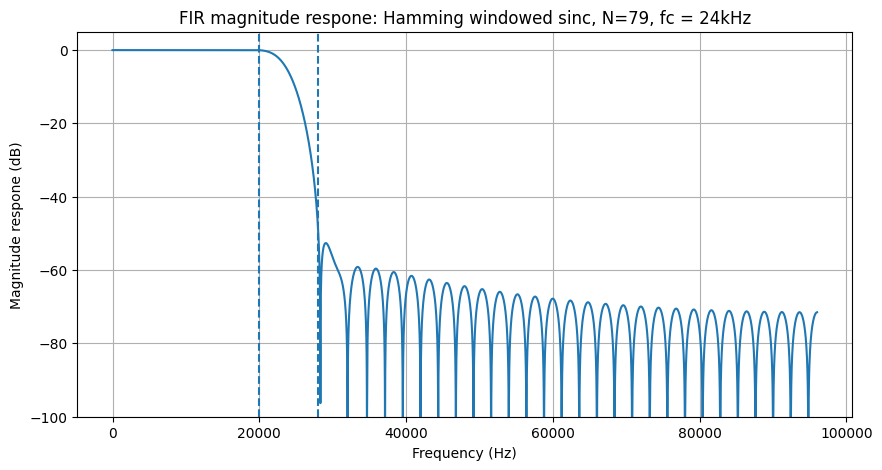

In [11]:
# Interpolation Filter Spec: 20kHz - 28kHz transition band, 
# >= 50dB attenuation, L = 4, upsample 48kHz -> 192 kHz
# Hamming window, k = 3.3 -> N = 3.3 * 192/(28kHz - 20kHz) = 79 taps
# fc = 24kHz

N = 79
fc = 24000
fs = 48000
fs_up = 4 * fs
hamming = signal.windows.hamming(N)
hann = signal.windows.hann(N)
blackman = signal.windows.blackman(N)
n = np.arange(N) - (N - 1) // 2
h_ideal = 2 * fc / fs_up * np.sinc( n * 2 * fc / fs_up )
h_coeffs = h_ideal * hamming

np.set_printoptions(suppress=True, precision=8)
print(', '.join('0' if x == 0 else f'{x:.8g}' for x in h_coeffs))


w, H = signal.freqz( h_coeffs, worN = 8192, fs = fs_up )
plt.figure( figsize = (10, 5))
plt.plot( w, 20 * np.log10(np.abs(H)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude respone (dB)')
plt.title('FIR magnitude respone: Hamming windowed sinc, N=79, fc = 24kHz')
plt.grid(True)
plt.ylim(-100, 5)
plt.axvline( 20000, linestyle='--' )
plt.axvline( 28000, linestyle='--' )
plt.show()








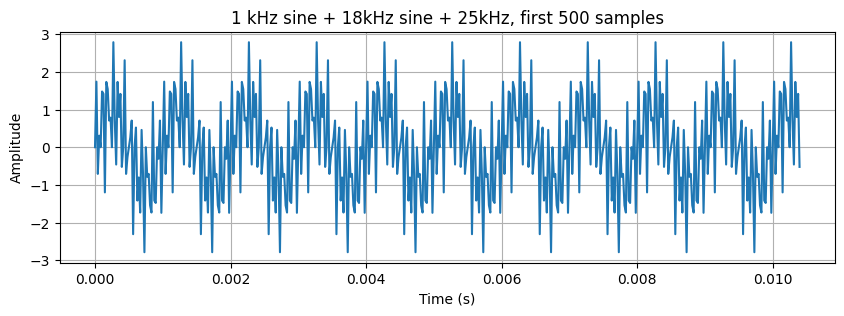

In [60]:
duration = 0.1
t = np.linspace(0, duration, int(fs * duration), endpoint = False)
test_signal = np.array([ np.sin(2 * np.pi * 1000 * sample ) for sample in t ])
test_signal += np.array([ np.sin(2 * np.pi * 12000 * sample ) for sample in t ])
test_signal += np.array([ np.sin(2 * np.pi * 19000 * sample ) for sample in t ])
plt.figure(figsize=(10, 3))
plt.plot(t[:500], test_signal[:500])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('1 kHz sine + 18kHz sine + 25kHz, first 500 samples')
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Zero-stuffed signal frequency response')

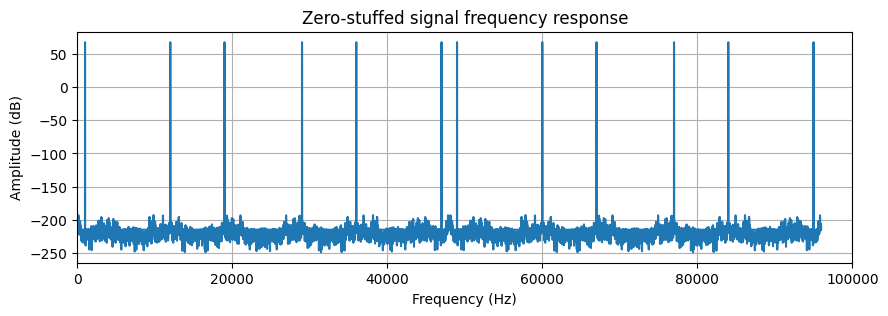

In [61]:

zeros = np.zeros(len(test_signal) * 4)
zeros[::4] = test_signal
zero_stuffed = zeros
np.set_printoptions(threshold=sys.maxsize)


test_spectra = fft(zero_stuffed)
freq_bins = fftfreq(len(zero_stuffed), d=1.0/fs_up)

plt.figure(figsize=(10, 3))
plt.plot( freq_bins, 20*np.log10(np.abs(test_spectra)) + 1e-12 )
plt.xlim(0, 100000)
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.title('Zero-stuffed signal frequency response')


Text(0.5, 1.0, 'Zero-stuffed signal frequency response')

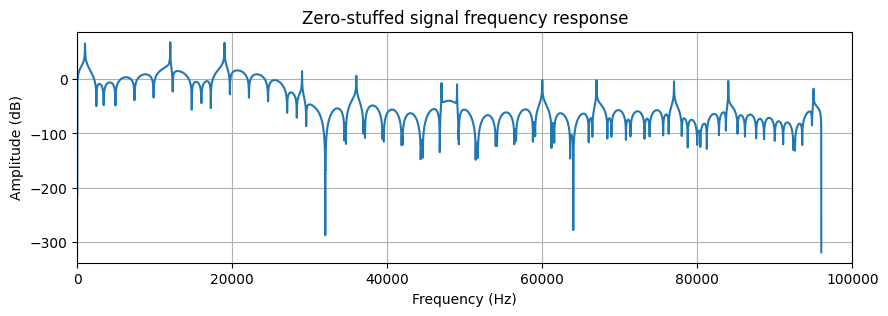

In [76]:
from numpy.fft import rfft, rfftfreq
filtered_signal = np.convolve(zero_stuffed, h_coeffs)
filtered_spectra = rfft(filtered_signal)
filt_bins = rfftfreq( len(filtered_signal), d=1.0/fs_up )

plt.figure(figsize=(10, 3))
plt.plot( filt_bins, 20*np.log10(np.abs(filtered_spectra)) + 1e-12 )
plt.xlim(0, 100000)
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.title('Zero-stuffed signal frequency response')

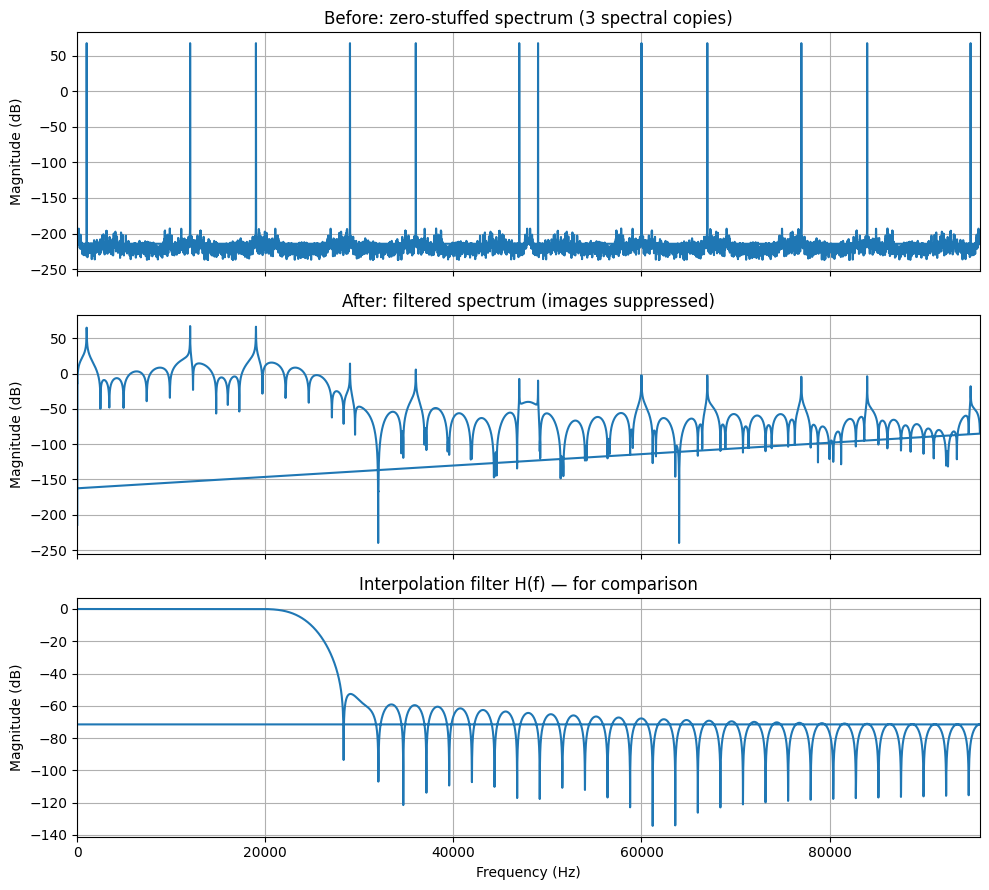

In [71]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# --- rebuild the pipeline cleanly ---
L = 4
zero_stuffed = np.zeros(len(test_signal) * L)
zero_stuffed[::L] = test_signal

filtered_signal = np.convolve(zero_stuffed, h_coeffs)

# --- spectra ---
before_spec = fft(zero_stuffed)
before_bins = fftfreq(len(zero_stuffed), d=1.0/fs_up)

after_spec = fft(filtered_signal)
after_bins = fftfreq(len(filtered_signal), d=1.0/fs_up)

# filter's own response, zero-padded to the filtered length so it
# overlays on the same frequency axis as the after spectrum
H = fft(h_coeffs, len(filtered_signal))
H_bins = fftfreq(len(filtered_signal), d=1.0/fs_up)

def db(x):
    return 20 * np.log10(np.abs(x) + 1e-12)

# --- three stacked plots, shared x-axis ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

ax1.plot(before_bins, db(before_spec))
ax1.set_title('Before: zero-stuffed spectrum (3 spectral copies)')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True)

ax2.plot(after_bins, db(after_spec))
ax2.set_title('After: filtered spectrum (images suppressed)')
ax2.set_ylabel('Magnitude (dB)')
ax2.grid(True)

ax3.plot(H_bins, db(H))
ax3.set_title('Interpolation filter H(f) — for comparison')
ax3.set_ylabel('Magnitude (dB)')
ax3.set_xlabel('Frequency (Hz)')
ax3.grid(True)

ax1.set_xlim(0, fs_up / 2)   # shared, so this sets all three
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
def filterCoefficients(fc, q, gaindB, fs):
    
    w0 = 2 * np.pi * fc / fs;
    alpha = np.sin( w0 ) / ( 2 * q );
    A = pow( 10, gaindB / 40 );
    
    a0 = 1 + alpha;
    a1 = -2 * np.cos( w0 ) / a0;
    a2 = ( 1 - alpha ) / a0;
    b0 = ( 1 - np.cos( w0 )) / ( 2 * a0 );
    b1 = (1 - np.cos( w0 )) / a0;
    b2 = b0;

    return a1, a2, b0, b1, b2

print(filterCoefficients(1000, 0.707, 0, 48000))
    

(np.float64(-1.8153179156742147), np.float64(0.8309822224090126), np.float64(0.0039160766836994635), np.float64(0.007832153367398927), np.float64(0.0039160766836994635))
